# Atelier Préparation de Données Textuelles

- Contexte 

Une entreprise souhaite développer un système capable de classer automatiquement des avis 
clients afin d'identifier leur sentiment. 

Les avis proviennent de plusieurs sources : site web, application mobile, formulaire de satisfaction, 
réseaux sociaux et service client. 

Les données collectées sont cependant de qualité variable : textes vides, doublons, fautes de frappe, 
majuscules/minuscules, caractères spéciaux, emojis, URLs, mentions, répétitions de caractères, 
textes très courts ou très longs, plusieurs catégories de sentiment et quelques valeurs manquantes. 
Avant de construire un modèle de Machine Learning ou de Deep Learning, les apprenants doivent 
donc construire un pipeline complet de préparation des données textuelles.

- Structure du projet 

atelier_prepa_donnees_textuelles/ 

│ 
├──         notebooks/ 

│   
└──_____________atelier_prepa_donnees_textuelles.ipynb 

│  
└──          __data/ 

├── ___________smart_reviews_raw.csv 

├── ____________smart_reviews_cleaned.csv 

└── _____________tfidf_matrix.npz 

# Partie 1 – Exploration du corpus

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

1) Charger les données CSV ; 

In [2]:
df = pd.read_csv("../data/smart_reviews_raw.csv")

2) Combien d'avis contient le dataset ?

In [22]:
nb_avis = len(df)
print("Nombre d'avis:", nb_avis)

Nombre d'avis: 1200


3) Combien de colonnes possède-t-il ? 

In [24]:
nb_colonnes = df.shape[1]
print("Nombre de colonnes:", nb_colonnes)

Nombre de colonnes: 8


4) Quel est le type de chaque colonne ? 

In [30]:
df.dtypes

id_avis      object
date         object
source       object
produit      object
texte        object
sentiment    object
note          int64
langue       object
dtype: object

5) Existe-t-il des valeurs manquantes ? 

In [43]:
df.isnull().sum()

id_avis       0
date          0
source        0
produit       0
texte         5
sentiment     0
note          0
langue        0
type_texte    0
dtype: int64

6) Identifier quelques types de texte en affichant par exemple : 

-  texte normal ;

In [31]:
df["type_texte"] = "texte normal"

df.loc[df["texte"].isna(), "type_texte"] = "texte vide"
df.loc[df["texte"].astype(str).str.strip() == "", "type_texte"] = "texte vide"

df[["texte", "type_texte"]]

,texte,type_texte
0,"Très bonne expérience, simple et efficace.",texte normal
1,Très satisfait de mon achat 👍 #avis,texte normal
2,"Produit parfait, rien à signaler.",texte normal
3,"Produit excellent, je suis très satisfait. !!!",texte normal
4,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...,texte normal
...,...,...
1195,La batterie se décharge beaucoup trop vite.,texte normal
1196,"Très bonne expérience, simple et efficace. !!!",texte normal
1197,Produit correct pour son prix. !!!,texte normal
1198,Excellent rapport qualité-prix. #avis,texte normal


- texte vide

In [44]:
texte = df["texte"].fillna("")
df.loc[
    texte.str.strip() == "",
    ["texte"]
]

,texte
46,NaN
108,NaN
310,NaN
640,NaN
781,NaN
951,


- Texte contenant une URL

In [45]:
df.loc[
    texte.str.contains(
        r"https?://|www\.",
        case=False,
        regex=True
    ),
    ["texte"]
]

,texte
16,"Produit parfait, rien à signaler. https://exam..."
30,"Très bonne expérience, simple et efficace. htt..."
31,"Je viens de recevoir le produit, à voir dans l..."
34,"Produit parfait, rien à signaler. https://exam..."
35,"Très bon produit, la qualité est au rendez-vou..."
...,...
1169,"Très bonne expérience, simple et efficace. htt..."
1172,La batterie tient vraiment bien et l'écran est...
1185,Excellent rapport qualité-prix. https://exampl...
1191,L'utilisation est assez simple. https://exampl...


In [48]:
### Comptage des texte contenant des URL
texte.str.contains(
    r"https?://|www\.",
    regex=True
).sum()

np.int64(143)

- texte contenant une mention 


In [46]:
df.loc[
    texte.str.contains(
        r"@\w+",
        regex=True
    ),
    ["texte"]
]

,texte
9,@client Livraison rapide et produit conforme à...
32,@client Service client réactif et commande reç...
40,@client La qualité est correcte sans être exce...
44,"@client Je recommande vivement, tout fonctionn..."
45,@client Excellent rapport qualité-prix.
...,...
1151,@client La livraison s'est déroulée normalement.
1155,@client Excellent rapport qualité-prix.
1175,@client Excellent rapport qualité-prix.
1193,"@client Très bonne expérience, simple et effic..."


In [47]:
#### Comptage des mentions
texte.str.contains(
    r"@\w+",
    regex=True
).sum()

np.int64(128)

- texte contenant un hashtag

In [49]:
df.loc[
    texte.str.contains(
        r"#\w+",
        regex=True
    ),
    ["texte"]
]

,texte
1,Très satisfait de mon achat 👍 #avis
12,La batterie tient vraiment bien et l'écran est...
15,Produit correct pour son prix. #avis
38,"Très bonne expérience, simple et efficace. #avis"
69,La batterie tient vraiment bien et l'écran est...
...,...
1163,Le produit correspond globalement à la descrip...
1166,Le service client n'a pas répondu à ma demande...
1179,"Produit parfait, rien à signaler. #avis"
1194,"Très bon produit, la qualité est au rendez-vou..."


In [51]:
texte.str.contains(
        r"#\w+",
        regex=True
    ).sum()

np.int64(127)

- texte contenant des emojis 

In [52]:
df.loc[
    texte.str.contains(
        r"[\U0001F300-\U0001FAFF]",
        regex=True
    ),
    ["texte"]
]

,texte
1,Très satisfait de mon achat 👍 #avis
5,Très satisfait de mon achat 👍 😊
7,Très satisfait de mon achat 👍
10,Très satisfait de mon achat 👍 !!!
19,"Je viens de recevoir le produit, à voir dans l..."
...,...
1176,Le produit correspond globalement à la descrip...
1180,Excellent rapport qualité-prix. 😊
1181,Très satisfait de mon achat 👍 😊
1187,Très satisfait de mon achat 👍


In [53]:
## Comptage des textes avec emojis
texte.str.contains(
        r"[\U0001F300-\U0001FAFF]",
        regex=True
    ).sum()


np.int64(192)

- texte avec beaucoup de ponctuation 

Nous devons d'abord décider ce que signifie « beaucoup ».

Pour notre atelier, nous pouvons considérer qu'un texte possède beaucoup de ponctuation lorsque 30 % ou plus de ses caractères sont des signes de ponctuation.

Commençons par compter les caractères de ponctuation 

In [56]:
nombre_ponctuation = texte.str.count(r"[^\w\s]") ### Comptage des caracteres de ponctuation
longueur_texte = texte.str.len() #### Longueur du texte
df.loc[
    (longueur_texte > 0) &
    ((nombre_ponctuation / longueur_texte) >= 0.30),
    ["texte"]
]


,texte
952,super produit!!!!!!!!!!!!!!!!!!!!!!!!


In [57]:
(
    (longueur_texte > 0) &
    ((nombre_ponctuation / longueur_texte) >= 0.30)
).sum()

np.int64(1)

 - texte en majuscules

In [58]:
## Verifions d'abord qu'il contient au moins une lettre
contient_lettre = texte.str.contains(
    r"[A-Za-zÀ-ÖØ-öø-ÿ]",
    regex=True
)

In [59]:
df.loc[
    contient_lettre &
    (texte == texte.str.upper()),
    ["texte"]
]

,texte
4,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...
6,SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPID...
17,SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPID...
23,"PRODUIT EXCELLENT, JE SUIS TRÈS SATISFAIT."
24,TRÈS SATISFAIT DE MON ACHAT 👍
...,...
1145,"MAUVAISE EXPÉRIENCE, JE NE RECOMMANDE PAS."
1167,LIVRAISON RAPIDE ET PRODUIT CONFORME À MES ATT...
1174,"TRÈS BON PRODUIT, LA QUALITÉ EST AU RENDEZ-VOUS."
1184,SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPID...


In [60]:
## Comptage 
(
    contient_lettre &
    (texte == texte.str.upper())
).sum()

np.int64(146)

- texte avec 
répétition de caractères. 

In [61]:
df.loc[
    texte.str.contains(
        r"(.)\1{2,}",
        regex=True
    ),
    ["texte"]
]

C:\Users\bmd\AppData\Local\Temp\ipykernel_8788\1325051527.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  texte.str.contains(


,texte
3,"Produit excellent, je suis très satisfait. !!!"
10,Très satisfait de mon achat 👍 !!!
14,Qualité décevante pour ce prix. !!!
25,"Produit reçu endommagé, je suis mécontent. !!!"
28,"Produit excellent, je suis trèèès satisfait."
...,...
1183,"Je recommande vivement, tout fonctionne parfai..."
1186,"Très bonne expérience, simple et efficace. !!!"
1190,La batterie tient vraiment bien et l'écran est...
1196,"Très bonne expérience, simple et efficace. !!!"


In [62]:
## comptage 
texte.str.contains(
    r"(.)\1{2,}",
    regex=True
).sum()

C:\Users\bmd\AppData\Local\Temp\ipykernel_8788\604504094.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  texte.str.contains(


np.int64(165)

In [63]:
df["est_vide"] = texte.str.strip() == ""

In [64]:
df["contient_url"] = texte.str.contains(
    r"https?://|www\.",
    case=False,
    regex=True
)

In [65]:
df["contient_mention"] = texte.str.contains(
    r"@\w+",
    regex=True
)

In [66]:
df["contient_hashtag"] = texte.str.contains(
    r"#\w+",
    regex=True
)

In [67]:
df["contient_emoji"] = texte.str.contains(
    r"[\U0001F300-\U0001FAFF]",
    regex=True
)

In [68]:
df["beaucoup_ponctuation"] = (
    (longueur_texte > 0) &
    ((nombre_ponctuation / longueur_texte) >= 0.30)
)

In [69]:
df["est_majuscules"] = (
    contient_lettre &
    (texte == texte.str.upper())
)

In [70]:
df["repetition_caracteres"] = texte.str.contains(
    r"(.)\1{2,}",
    regex=True
)

C:\Users\bmd\AppData\Local\Temp\ipykernel_8788\993799879.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["repetition_caracteres"] = texte.str.contains(


In [71]:
df[
    [
        "texte",
        "est_vide",
        "contient_url",
        "contient_mention",
        "contient_hashtag",
        "contient_emoji",
        "beaucoup_ponctuation",
        "est_majuscules",
        "repetition_caracteres"
    ]
].head(20)

,texte,est_vide,contient_url,contient_mention,contient_hashtag,contient_emoji,beaucoup_ponctuation,est_majuscules,repetition_caracteres
0,"Très bonne expérience, simple et efficace.",False,False,False,False,False,False,False,False
1,Très satisfait de mon achat 👍 #avis,False,False,False,True,True,False,False,False
2,"Produit parfait, rien à signaler.",False,False,False,False,False,False,False,False
3,"Produit excellent, je suis très satisfait. !!!",False,False,False,False,False,False,False,True
4,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...,False,False,False,False,False,False,True,False
5,Très satisfait de mon achat 👍 😊,False,False,False,False,True,False,False,False
6,SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPID...,False,False,False,False,False,False,True,False
7,Très satisfait de mon achat 👍,False,False,False,False,True,False,False,False
8,Le produit correspond globalement à la d...,False,False,False,False,False,False,False,False
9,@client Livraison rapide et produit conforme à...,False,False,True,False,False,False,False,False


7) Mesurer la longueur des textes en créant une nouvelle colonne « longueur » pour déterminer : 
longueur minimale ; longueur maximale ; longueur moyenne ; médiane et quartiles. 

- La longueur des textes

In [73]:
df["longueur"] = texte.str.len()
df[["texte", "longueur"]].head(10)

,texte,longueur
0,"Très bonne expérience, simple et efficace.",47
1,Très satisfait de mon achat 👍 #avis,35
2,"Produit parfait, rien à signaler.",37
3,"Produit excellent, je suis très satisfait. !!!",46
4,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...,55
5,Très satisfait de mon achat 👍 😊,31
6,SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPID...,52
7,Très satisfait de mon achat 👍,34
8,Le produit correspond globalement à la d...,57
9,@client Livraison rapide et produit conforme à...,60


- Longueur minimale

In [ ]:
#df["longueur"].min()
df[["longueur"]].min().

longueur    0
dtype: int64

- Longueur maximale

In [85]:
df["longueur"].max()

636

- Longueur moyenne

In [ ]:
df[["longueur"]].mean()

longueur    48.963333
dtype: float64

- La mediane

In [ ]:
df[["longueur"]].median()

longueur    48.0
dtype: float64

- Les quartiles

In [84]:
df[["longueur"]].quantile([0.25, 0.50, 0.75])

,longueur
0.25,37.0
0.50,48.0
0.75,56.0


8) Visualiser la distribution de la longueur des avis puis répondre aux questions 

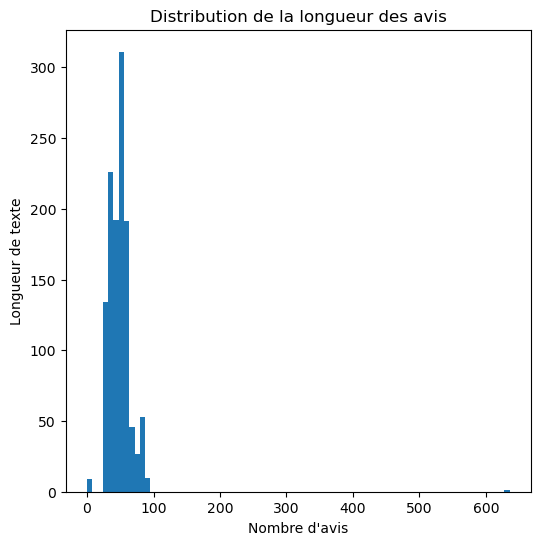

In [111]:
plt.figure(figsize=(6, 6))

plt.hist(df["longueur"], bins=80)

plt.xlabel("Nombre d'avis")
plt.ylabel("Longueur de texte")
plt.title("Distribution de la longueur des avis")

plt.show()

Analyse de l'histogramme:la visualisation de cet histogramme nous montre qu'effectivement il y a des textes anormalement longs et beaucoup de textes tres courts


a) Existe-t-il des textes anormalement longs ? 

In [105]:
Q1 = df["longueur"].quantile(0.25)
Q3 = df["longueur"].quantile(0.75)

IQR = Q3 - Q1

In [106]:
seuil_superieur = Q3 + 1.5 * IQR

In [107]:
df.loc[
    df["longueur"] > seuil_superieur,
    ["texte", "longueur"]
]

,texte,longueur
31,"Je viens de recevoir le produit, à voir dans l...",86
51,"Je viens de recevoir le produit, à voir dans l...",86
110,La batterie tient vraiment bien et l'écran est...,88
123,Service client réactif et commande reçue rapid...,85
145,Livraison rapide et produit conforme à mes att...,85
294,"Je recommande vivement, tout fonctionne parfai...",86
306,"Je viens de recevoir le produit, à voir dans l...",87
313,"Je viens de recevoir le produit, à voir dans l...",87
318,La batterie tient vraiment bien et l'écran est...,88
340,"Je viens de recevoir le produit, à voir dans l...",87


In [108]:
(df["longueur"] > seuil_superieur).sum()

np.int64(41)

Nous avons identifié 41 textes qui dépassaient le seuil fqisqnt d'eux des textes anormalement longs.

b) Existe-t-il beaucoup de textes très courts ? 

In [112]:
##### les textes ayant moins de 20 caracteres sont consideres comme tres courts
df.loc[
    df["longueur"] < 20,
    ["texte", "longueur"]
]

,texte,longueur
46,NaN,0
108,NaN,0
224,OK,2
310,NaN,0
554,Pas bon,7
640,NaN,0
781,NaN,0
889,OK,2
951,,3


In [113]:
(df["longueur"] < 20).sum()  ### Comptage 

np.int64(9)